# Variant Attribution


**Issues**: 
- `hap_matrix` rows should ideally include all haplotypes, not just unique ones. This makes it easier to match up rows to sample IDs with `np.repeat(ds.samples, 2)`.
- When we want to create `hap_matrix` for an entire gene, we want to take the min/max coordinates of all the regions that correspond to that gene and create a new matrix without redundant variant cols. I suppose this could be done by create new GVL datasets with gene-wise start/end coordinates. But if there's a way to this with our existing site-centered GVL datasets that would be nice.
- Currently, if I pass multiple regions to `get_hap_matrix` is grows the matrix along the haplotype dimension (rows). We want it to only grow via the WT variant dimension (cols).
- We'd like to include identifiers for each WT variant (col). e.g. *HGVS:g.5000A>G* or *HGVS:g.77_80del*


In [2]:
%load_ext autoreload
%autoreload 2

import os
# only load this one time per session
if 'NOTEBOOK_INITIALIZED' not in globals():
    os.chdir(os.path.dirname(os.path.abspath('.')))
    NOTEBOOK_INITIALIZED = True
import pandas as pd
import polars as pl
import numpy as np
import glob 
from tqdm import tqdm 
import seaborn as sns
import matplotlib.pyplot as plt
import pooch

import src.utils as utils
import src.vep_analysis as va
import src.clinvar as cv
import src.onekg as og
import src.benchmark.clinvar as bcv
import src.GVL as GVL
import src.analysis.attribution as ab
import src.analysis.matrices as mc


pd.set_option('display.max_columns', None)
import genvarloader as gvl
import awkward as ak


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Determine genes of interest

Grab the region that corresponds to the one centered on each clinical variant.

Sort genes based on how many pathogenic variants that have, as these are less common in ClinvVar than benign variants (at least in UTRs).

In [42]:
## Select chrom of interest
chrom="chr17"

bed = pd.read_csv("data/splicing/splicevardb_x_clinvar_variants.csv.gz")

bed = utils.add_variant_name(bed, chrom_col="chr", start_col="pos", end_col=None, ref_col="ref", alt_col="alt", alias="site")
bed.rename(columns={"chr":"chrom","gene":"GENE","CLNSIG_simplified":"CLNSIG_simple"}, inplace=True)
site_counts = bed.groupby(["chrom","GENE","CLNSIG_simple"])["site"].nunique().sort_values(ascending=False).rename("n_sites").reset_index()
# # For each GENE, count the ratio of pathogenic to benign n_sites

# # First, filter for pathogenic and benign rows
path_mask = site_counts["CLNSIG_simple"].str.lower().str.contains("path")
benign_mask = site_counts["CLNSIG_simple"].str.lower().str.contains("benign")

# # Aggregate n_sites for each gene and class
gene_path = site_counts[path_mask].groupby(["chrom","GENE"])["n_sites"].sum().rename("n_path")
gene_benign = site_counts[benign_mask].groupby(["chrom","GENE"])["n_sites"].sum().rename("n_benign")

# Combine into a single DataFrame
gene_counts = pd.concat([gene_path, gene_benign], axis=1).fillna(0)

# Compute the ratio
gene_counts["path_to_benign_ratio"] = gene_counts["n_path"] / gene_counts["n_benign"].replace(0, np.nan)

# Optionally, sort by ratio descending
gene_counts = gene_counts.sort_values("n_path", ascending=False).reset_index()

print(gene_counts)  


## Get the top gene on the chromosome of interest
gene = gene_counts.loc[gene_counts["chrom"].str.replace("chr", "") == chrom.replace("chr", "")]['GENE'].values[0]
print("GENE:", gene)

      chrom    GENE  n_path  n_benign  path_to_benign_ratio
0     chr17   BRCA1   148.0     138.0              1.072464
1     chr17     NF1   124.0       4.0             31.000000
2     chr13   BRCA2   113.0      84.0              1.345238
3      chr3  COL7A1    91.0       5.0             18.200000
4      chr3    MLH1    69.0      25.0              2.760000
...     ...     ...     ...       ...                   ...
1304  chr16   ACSF3     0.0       1.0              0.000000
1305  chr16  ABCC12     0.0       1.0              0.000000
1306  chr16   AARS1     0.0       3.0              0.000000
1307  chr15    USP8     0.0       1.0              0.000000
1308   chrX    WWC3     0.0       3.0              0.000000

[1309 rows x 5 columns]
GENE: BRCA1


In [17]:
bed.groupby(["MC","CLNSIG_simple"])["site"].nunique()

MC                                                                                                       CLNSIG_simple
SO:0001574|splice_acceptor_variant                                                                       pathogenic       179
                                                                                                         vus               12
SO:0001574|splice_acceptor_variant,SO:0001583|missense_variant                                           vus                1
SO:0001574|splice_acceptor_variant,SO:0001583|missense_variant,SO:0001619|non-coding_transcript_variant  pathogenic         1
SO:0001574|splice_acceptor_variant,SO:0001623|5_prime_UTR_variant                                        pathogenic         2
                                                                                                                         ... 
SO:0001819|synonymous_variant                                                                            benign           757

In [19]:
window_size = 10000

# #### Take the union of all windows
# gene_min_pos = bed.loc[bed["GENE"]==gene]["chromStart"].min() - (window_size//2)
# gene_max_pos = bed.loc[bed["GENE"]==gene]["chromEnd"].max() + (window_size//2)

#### Take the intersection of all windows
gene_min_pos = bed.loc[bed["GENE"]==gene]["pos"].max() - (window_size//2)
gene_max_pos = bed.loc[bed["GENE"]==gene]["pos"].min() + (window_size//2)

print(gene_min_pos, gene_max_pos, abs(gene_min_pos-gene_max_pos))

43119125 43050802 68323


## Create haplotype x WT variant matrix: `genvarloader`

In [118]:
from src.SpliceAI.src.dataset import SpliceHapDataset
from pathlib import Path


chrom = bed.loc[bed["GENE"]==gene].chrom.iloc[0]

root_dir = Path(os.path.expanduser("~/projects/data/1000_Genomes_on_GRCh38/SpliceAI"))
data_dir = root_dir / "data/gvl_1kgp/1kgp_gvl/"
out_dir = root_dir / Path("out")
data_dir.mkdir(parents=True, exist_ok=True)
out_dir.mkdir(parents=True, exist_ok=True)

# 1. Get the path for 1KGP reference genome   
cohort = "1000_Genomes_on_GRCh38"
reference_path = pooch.retrieve(
        url=og.get_ftp_dict()[cohort]['ref'],
        known_hash=None,
        progressbar=True
    )
reference_bgz = Path(f"{reference_path}.bgz")
# Loop through each chromosome 
print(f"\n🔄 Processing {chrom}...")

variant_path = root_dir / Path(f"./data/splicevardb_x_clinvar/splicevardb_x_clinvar_snv_{chrom}.atomized.vcf.gz")
hap_pgen_path = root_dir / Path(f"./data/1000_Genomes_on_GRCh38/vcf/ALL.{chrom}.shapeit2_integrated_snvindels_v2a_27022019.GRCh38.phased.vcf.atomized.vcf.gz")
region_bed_path = root_dir / Path(f"./data/splicevardb_x_clinvar/splicevardb_x_clinvar_snv_{chrom}_region_bed.bed")
annotation_bed_path = [
    ("3pss", f"{root_dir}/data/annotation/p3_{chrom}_bed.bed"),
    ("5pss", f"{root_dir}/data/annotation/p5_{chrom}_bed.bed")
]

dataset_path = data_dir / f"{chrom}_dataset.gvl"
output_path = out_dir / f"{chrom}_results.parquet"

 # Build the dataset
dataset = SpliceHapDataset.build_from_files_with_matching_sites(
    reference_path=str(reference_path),
    region_bed_path=str(region_bed_path),
    hap_pgen_path=str(hap_pgen_path),
    variant_path=str(variant_path),
    window_size=50,
    context_size=5000,
    bed_paths=annotation_bed_path,
    dataset_path=str(dataset_path),
    ploidy=2,
    deduplicate=False,
    remake_dataset=False,  # Set False in future to avoid rebuilding
    num_workers=0,
    enable_profiling=False,
    enable_cache=True
)

site_ds = dataset.gvl

2025-09-23 17:26:29.681 | INFO     | genvarloader._dataset._reconstruct:from_path:215 - Loading variant data.
2025-09-23 17:26:29.744 | INFO     | genvarloader._dataset._impl:open:252 - Opened dataset:
GVL store at /home/schilder/projects/data/1000_Genomes_on_GRCh38/SpliceAI/data/gvl_1kgp/1kgp_gvl/chr17_dataset.gvl
Is subset: False
# of regions: 897
# of samples: 2548
Output length: ragged
Jitter: 0 (max: 0)
Deterministic: True
Sequence type: reference haplotypes annotated [variants]
Active tracks: 3pss_neg, 3pss_pos, 5pss_neg, 5pss_pos
Tracks available: 3pss_neg, 3pss_pos, 5pss_neg, 5pss_pos




🔄 Processing chr17...


Reading records:   0%|          | 0/897 [00:00<?, ? record/s]

In [ ]:
# Subset the GVL dataset to a regions of interest for a specific gene and compute the binarized haplotype x WT variant matrix.
region_to_site = GVL.filter_region_to_site(site_ds.rows) 
roi = region_to_site.filter(pl.col("chromStart") >=bed.loc[bed["GENE"]==gene]["pos"].min(),
                            pl.col("chromEnd") <= bed.loc[bed["GENE"]==gene]["pos"].max()
     )
print(roi.shape)
roi

Sites before filter_region_to_site:  (49585, 8)
Sites after site_filters:  (897, 9)
Sites after region_idx==site_idx filter:  (897, 9)
(199, 9)


index,region_idx,chrom,chromStart,chromEnd,site_idx,REF,ALT,POS0
u32,u32,cat,i64,i64,u32,str,str,i64
15436,436,"""chr17""",43048331,43078332,436,"""A""","""C""",43063330
15566,437,"""chr17""",43048347,43078348,437,"""T""","""A""",43063346
15696,438,"""chr17""",43048368,43078369,438,"""T""","""C""",43063367
15826,439,"""chr17""",43048369,43078370,439,"""C""","""A""",43063368
15956,440,"""chr17""",43048372,43078373,440,"""C""","""A""",43063371
…,…,…,…,…,…,…,…,…
39053,630,"""chr17""",43091529,43121530,630,"""A""","""C""",43106528
39187,631,"""chr17""",43091533,43121534,631,"""T""","""A""",43106532
39321,632,"""chr17""",43091534,43121535,632,"""C""","""G""",43106533


In [117]:
from genoray import VCF

vcf_path = os.path.expanduser(f"~/projects/data/1000_Genomes_on_GRCh38/vcf/ALL.{chrom}.shapeit2_integrated_snvindels_v2a_27022019.GRCh38.phased.vcf.gz")
vcf = VCF(vcf_path)

hap_ids, hap_membership, hap_matrix, col_v_idxs = GVL.get_merged_hap_xr(
    vcf = vcf, 
    ds = site_ds.dataset, 
    regions = roi["region_idx"].to_list(), 
    samples = slice(None),
    verbose = True
)

2025-09-23 17:24:26.488 | INFO     | genoray._vcf:_load_index:1076 - Loading genoray index.


[get_merged_hap_xr] VCF index loaded and validated.
[get_merged_hap_xr] Parsing index for regions and samples.
[get_merged_hap_xr] Calculating intersection of genotypes.


IndexError: cannot slice ListArray (of length 1014104) with [0]: index out of range while attempting to get index 0 (in compiled code: https://github.com/scikit-hep/awkward/blob/awkward-cpp-46/awkward-cpp/src/cpu-kernels/awkward_ListArray_getitem_next_array.cpp#L32)

Create named df from hap_matrix.

In [10]:
Xwt = GVL.hap_xr_to_df(hap_matrix)
print(Xwt.shape)
Xwt.iloc[:10, :10]

(5096, 14670)


,chr17:7414521-7414522_C_T,chr17:7414534-7414535_G_A,chr17:7414555-7414556_G_T,chr17:7414612-7414613_G_A,chr17:7414619-7414620_C_T,chr17:7414639-7414640_G_A,chr17:7414675-7414676_C_T,chr17:7414741-7414742_T_C,chr17:7414771-7414772_C_T,chr17:7414772-7414773_G_A
HG00096_0,False,False,False,True,False,False,False,False,False,False
HG00096_1,False,False,False,False,False,False,False,False,False,False
HG00097_0,False,False,False,False,False,False,False,True,False,False
HG00097_1,False,False,False,False,False,False,False,False,False,False
HG00099_0,False,False,False,False,False,False,False,False,False,False
HG00099_1,False,False,False,False,False,False,False,False,False,False
HG00100_0,False,False,False,False,False,False,False,False,False,False
HG00100_1,False,False,False,False,False,False,False,False,False,False
HG00101_0,False,False,False,False,False,False,False,False,False,False
HG00101_1,False,False,False,False,False,False,False,False,False,False


In [11]:
Xwt.sum(axis=0).describe()

count    14670.000000
mean       186.772256
std        701.646584
min          1.000000
25%          1.000000
50%          2.000000
75%         11.000000
max       5096.000000
dtype: float64

Count the number of variants in which there is no variation.

These are probably cases where almost everyone has the non-REF allele (i.e. the REF is not representative of population-derived data).

In [12]:
n_invariant_variants = (Xwt.nunique(axis=0) == 1).sum()
print(f"Number of variants with no variation (invariant columns): {n_invariant_variants}")


Number of variants with no variation (invariant columns): 2


### Read in VEP data

In [13]:
save_dir = os.path.expanduser("~/projects/data/1000_Genomes_on_GRCh38/clinvar_utr_snv")
pq_files = glob.glob(os.path.join(save_dir, "*.parquet")) 

pq_file_chrom = [x for x in pq_files if  chrom in x][0] 

### Polars sucks at scanning remote parquet files, but is SUPER fast for local files
import polars as pl
vep_df = pl.scan_parquet(pq_file_chrom).filter(
    pl.col("slot") == "COVR",
    pl.col("flashzoi").is_not_null()
).collect().to_pandas()

# vep_df = pd.read_parquet(pq_file_chrom)
# vep_df = vep_df.loc[vep_df["slot"] == "COVR"].dropna(subset=["flashzoi"])

vep_df["VEP"] = vep_df["flashzoi"]
print(vep_df.shape)
vep_df.head()

(2238022, 15)


,index,site,sample,ploid,slot,evo2_40b_base,evo2_7b_base,evo2_7b,spliceai_mm,spliceai,evo2_40b,flashzoi,dnabert2,__null_dask_index__,VEP
0,214116,chr17:7675232-7675233_G_A,REF,0,COVR,NaN,NaN,NaN,NaN,NaN,NaN,0.448245,NaN,214116,0.448245
1,214130,chr17:7675232-7675233_G_A,REF,1,COVR,NaN,NaN,NaN,NaN,NaN,NaN,0.561821,NaN,214130,0.561821
2,214144,chr17:7675232-7675233_G_A,HG00096,0,COVR,NaN,NaN,NaN,NaN,NaN,NaN,0.469391,NaN,214144,0.469391
3,214158,chr17:7675232-7675233_G_A,HG00096,1,COVR,NaN,NaN,NaN,NaN,NaN,NaN,0.530744,NaN,214158,0.530744
4,214172,chr17:7675232-7675233_G_A,HG00097,0,COVR,NaN,NaN,NaN,NaN,NaN,NaN,0.745940,NaN,214172,0.745940


In [14]:
y_vep = vep_df.loc[vep_df["site"].isin(bed.loc[bed["GENE"] == gene]["site"])].pivot_table(
    index=["sample", "ploid"], 
    columns="site", 
    values="VEP"
)
# Flatten the MultiIndex for the rows
y_vep.index = [f"{s}_{p}" for s, p in y_vep.index]
print(y_vep.shape)
y_vep

(5098, 87)


site,chr17:7668539-7668540_G_A,chr17:7668783-7668784_C_T,chr17:7669124-7669125_C_T,chr17:7669200-7669201_G_T,chr17:7669252-7669253_A_G,chr17:7669404-7669405_C_T,chr17:7669603-7669604_A_T,chr17:7669628-7669629_T_G,chr17:7669640-7669641_A_G,chr17:7669641-7669642_T_C,chr17:7669655-7669656_C_A,chr17:7669655-7669656_C_T,chr17:7669656-7669657_G_T,chr17:7669671-7669672_C_G,chr17:7670613-7670614_A_C,chr17:7670616-7670617_G_A,chr17:7670630-7670631_C_G,chr17:7670643-7670644_C_G,chr17:7670649-7670650_G_T,chr17:7670658-7670659_T_A,chr17:7670664-7670665_C_A,chr17:7670669-7670670_G_T,chr17:7670678-7670679_A_G,chr17:7670684-7670685_C_G,chr17:7670684-7670685_C_T,chr17:7670685-7670686_G_A,chr17:7670694-7670695_C_A,chr17:7670694-7670695_C_G,chr17:7670699-7670700_C_A,chr17:7670699-7670700_C_G,chr17:7670699-7670700_C_T,chr17:7670700-7670701_G_A,chr17:7670706-7670707_G_A,chr17:7670709-7670710_C_A,chr17:7670711-7670712_C_T,chr17:7670712-7670713_G_A,chr17:7675136-7675137_G_A,chr17:7675136-7675137_G_T,chr17:7675139-7675140_C_A,chr17:7675139-7675140_C_G,chr17:7675139-7675140_C_T,chr17:7675142-7675143_A_C,chr17:7675143-7675144_C_A,chr17:7675143-7675144_C_T,chr17:7675145-7675146_C_G,chr17:7675148-7675149_G_T,chr17:7675157-7675158_G_A,chr17:7675157-7675158_G_C,chr17:7675160-7675161_G_C,chr17:7675161-7675162_G_A,chr17:7675161-7675162_G_C,chr17:7675161-7675162_G_T,chr17:7675174-7675175_C_T,chr17:7675175-7675176_C_T,chr17:7675182-7675183_G_A,chr17:7675184-7675185_A_G,chr17:7675185-7675186_C_T,chr17:7675189-7675190_G_C,chr17:7675190-7675191_C_T,chr17:7675200-7675201_C_G,chr17:7675206-7675207_G_A,chr17:7675208-7675209_C_A,chr17:7675209-7675210_A_C,chr17:7675209-7675210_A_G,chr17:7675212-7675213_A_T,chr17:7675214-7675215_A_G,chr17:7675216-7675217_C_A,chr17:7675216-7675217_C_G,chr17:7675217-7675218_T_C,chr17:7675220-7675221_T_A,chr17:7675223-7675224_A_G,chr17:7675232-7675233_G_A,chr17:7675232-7675233_G_T,chr17:7675233-7675234_A_G,chr17:7675234-7675235_G_C,chr17:7675237-7675238_C_A,chr17:7675237-7675238_C_T,chr17:7675238-7675239_T_A,chr17:7675238-7675239_T_C,chr17:7676257-7676258_G_A,chr17:7676262-7676263_G_T,chr17:7676264-7676265_C_G,chr17:7676405-7676406_T_C,chr17:7676567-7676568_C_G,chr17:7676567-7676568_C_T,chr17:7676574-7676575_A_T,chr17:7676584-7676585_G_A
HG00096_0,0.604416,0.404797,0.637196,0.705528,0.772902,0.431901,0.710960,0.871095,0.655572,0.490663,1.903873,1.296783,0.714747,3.842743,0.695757,0.540592,0.527767,0.939643,0.653625,0.421821,0.452608,0.662092,0.856164,0.418747,0.561543,0.635714,0.832877,0.917945,0.679168,0.367160,0.399399,0.756079,0.799252,1.559614,1.470508,0.525051,0.775228,0.527839,0.929709,0.524692,0.807440,0.675264,1.275547,0.898655,0.873243,0.527870,0.693418,0.577522,0.676868,0.665306,0.716007,0.695507,0.525274,0.903124,0.680605,0.652214,0.457992,0.626234,0.744840,0.550942,0.709204,0.926543,0.440275,0.732755,0.525295,0.793647,0.742282,0.322391,2.018385,0.263450,0.881696,0.469391,0.576449,0.574412,0.280914,4.241196,3.694795,3.498294,2.339327,0.405558,0.621161,0.444897,8.780553,0.342673,0.459971,0.303040,0.646036
HG00096_1,0.609664,0.000000,0.923833,0.622130,0.819998,0.818646,0.698355,2.009337,1.039084,0.824180,1.101100,1.412757,0.645641,3.960548,0.768043,0.619940,0.718180,0.334332,0.498606,0.513452,0.729964,0.711990,0.685931,0.453935,0.399402,0.545140,1.000844,1.245178,0.665041,0.415986,0.479595,0.723567,0.805475,1.490638,1.244580,0.716980,0.879653,0.716210,0.759906,0.642890,0.696206,0.662248,0.888679,0.834521,0.866173,0.604123,0.973804,0.931842,0.787607,0.926843,1.010343,0.762159,0.749162,0.752496,0.937694,0.578104,0.663065,0.555111,0.895079,0.542395,0.751038,0.885251,0.504358,0.816954,0.424103,0.786048,0.542908,0.443325,1.203294,0.226638,0.766998,0.530744,1.135694,0.600308,0.704711,2.941156,2.492344,3.162470,1.316859,0.467283,1.846734,0.417917,8.811554,0.579494,0.521739,0.359892,0.601221
HG00097_0,0.623922,0.000000,0.642184,0.686990,0.829997,0.519107,0.619227,1.072574,0.685120,0.727906,1.597972,0.783585,0.680931,2.975962,0.802708,0.

## Train ridge regression model

In [15]:
wtvariants_to_vep_linear_model_out = ab.wtvariants_to_vep_linear_model(Xwt, y_vep, 
                                                                       add_positions=True)

# Merge with variant metadata
ridge_df = wtvariants_to_vep_linear_model_out["interaction_df"]
ridge_df = ridge_df.merge(bed, on="site",how="left") 

Dropped 2 haplotypes due to NaNs in input or target matrices.


### Explore WT-Clinical variant interaction coefficients

Unnormalized

Normalizing rows
(14670, 87)


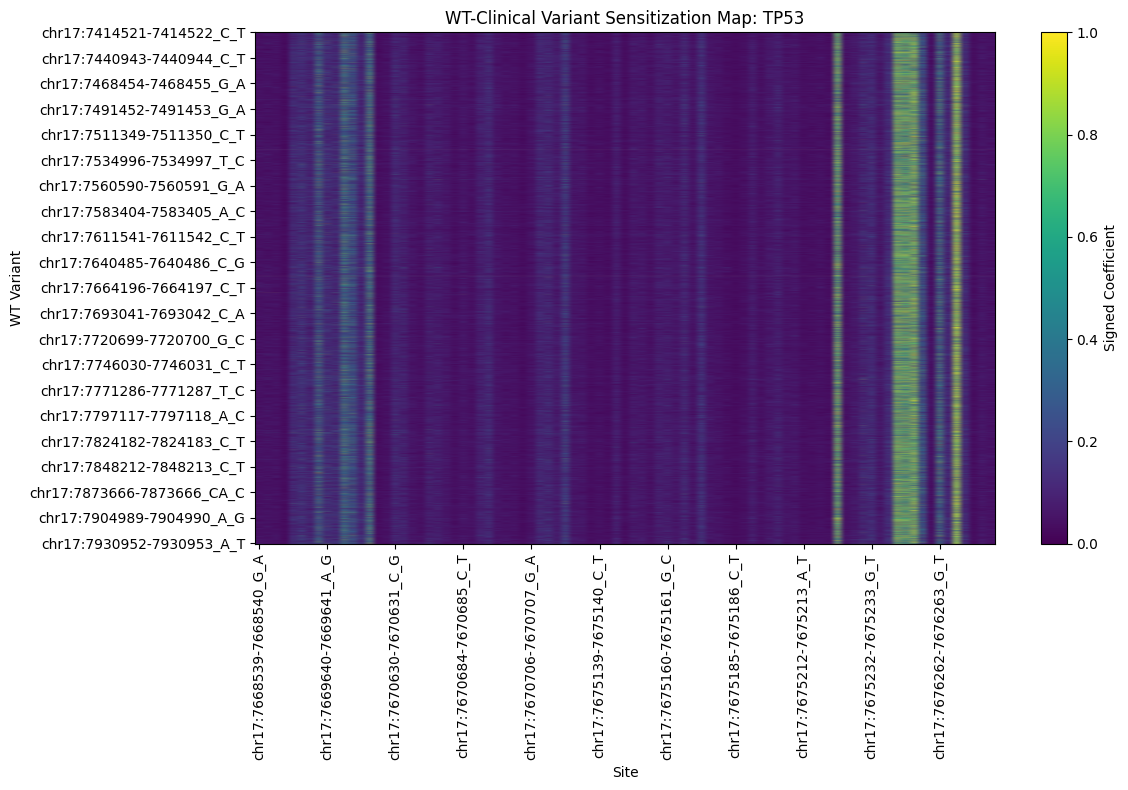

In [16]:
Xcoef = wtvariants_to_vep_linear_model_out["coef_matrix_abs"]

# Min-max normalize the columns of Xcoef
Xcoef = mc.minmax_normalize(Xcoef, procedure=["rows",])
# Xcoef = np.log10(Xcoef + 1e-6)

print(Xcoef.shape)

plt.figure(figsize=(12, 8))
im = plt.imshow(Xcoef.values, aspect='auto', cmap='viridis')
plt.colorbar(im, label="Signed Coefficient")
plt.xlabel("Site")
plt.ylabel("WT Variant")
plt.title(f"WT-Clinical Variant Sensitization Map: {gene}")
plt.xticks(
    ticks=range(0, Xcoef.shape[1], max(1, Xcoef.shape[1] // 10)),
    labels=Xcoef.columns[::max(1, Xcoef.shape[1] // 10)],
    rotation=90
)
plt.yticks(
    ticks=range(0, Xcoef.shape[0], max(1, Xcoef.shape[0] // 20)),
    labels=Xcoef.index[::max(1, Xcoef.shape[0] // 20)]
)
plt.tight_layout()
plt.show()


Unnormalized + clustered WTs variants (rows)

Text(0.5, 0.98, 'WT-Clinical Variant Sensitization Map: TP53')

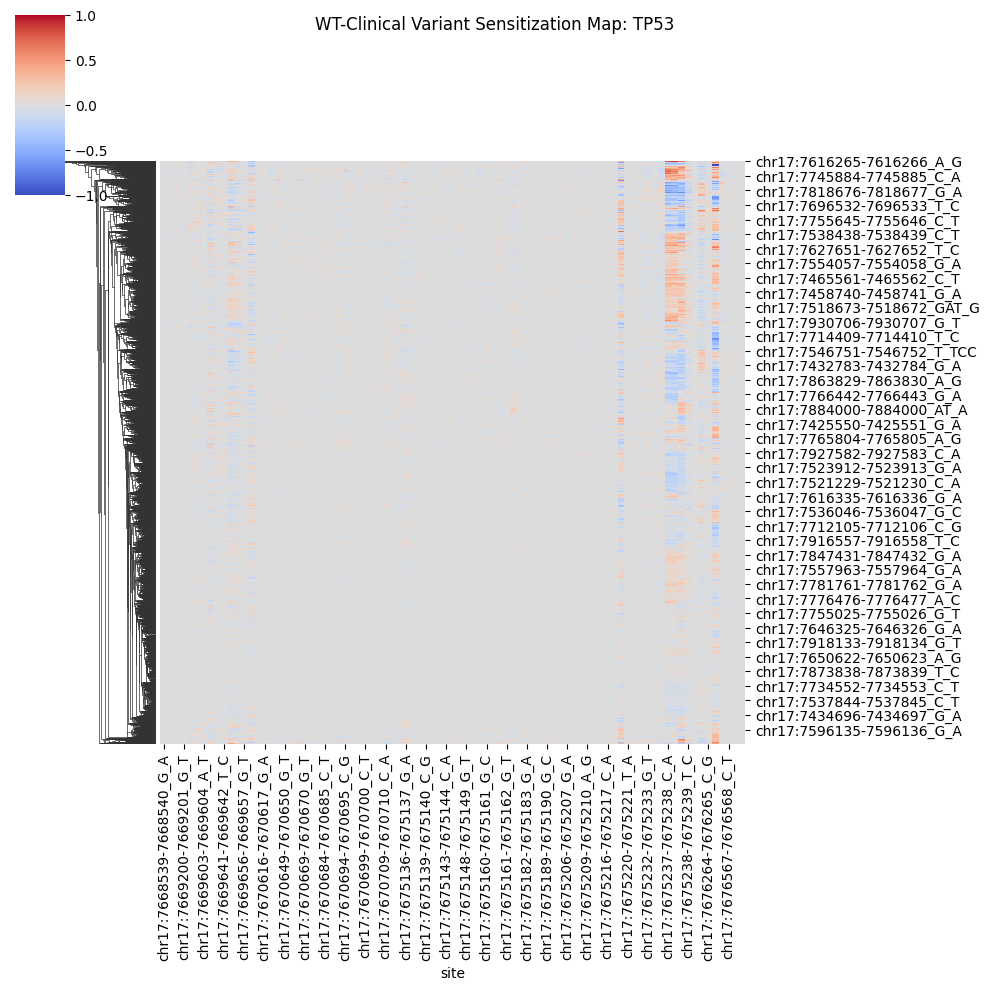

In [76]:
Xcoef = wtvariants_to_vep_linear_model_out["coef_matrix_signed"]
Xcoef = Xcoef[Xcoef.nunique(axis=1) > 1]
 
g = sns.clustermap(Xcoef, 
                    cmap='coolwarm', 
                    row_cluster=True,
                    col_cluster=False,
                    vmin=-1, vmax=1
                    ) 
g.fig.suptitle(f"WT-Clinical Variant Sensitization Map: {gene}")


Normalized (column-wise) + clustered WTs variants (rows).

Considering absolute interaction coefficients (rather than signed).

Normalizing rows


Text(0.5, 0.98, 'WT-Clinical Variant Sensitization Map: TP53')

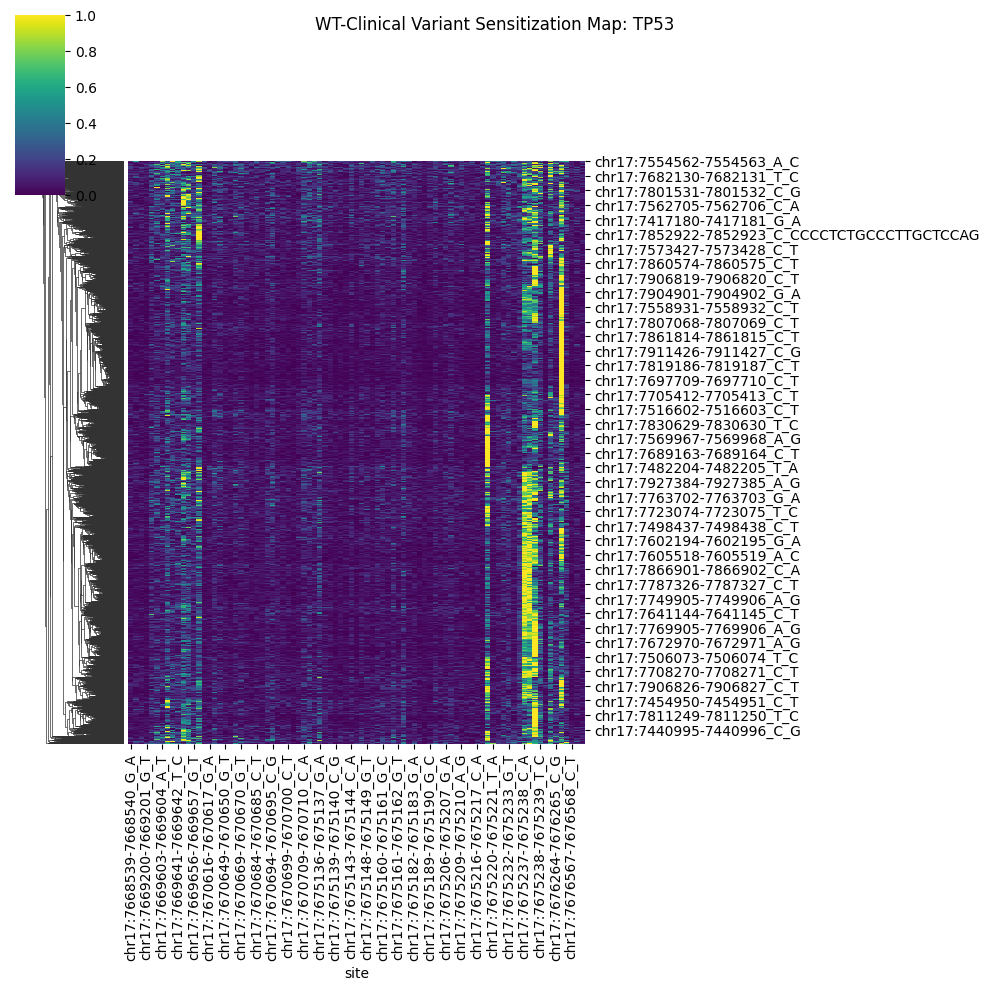

In [77]:
Xcoef = wtvariants_to_vep_linear_model_out["coef_matrix_abs"]
Xcoef = Xcoef[Xcoef.nunique(axis=1) > 1]
 

Xcoef = mc.minmax_normalize(Xcoef, procedure=["rows",])

g = sns.clustermap(Xcoef, 
                    cmap='viridis', 
                    row_cluster=True,
                    col_cluster=False,
                    # vmin=-1, vmax=1
                    ) 
g.fig.suptitle(f"WT-Clinical Variant Sensitization Map: {gene}")


Test whether there's a relationships between genomic position distance and interaction strength.

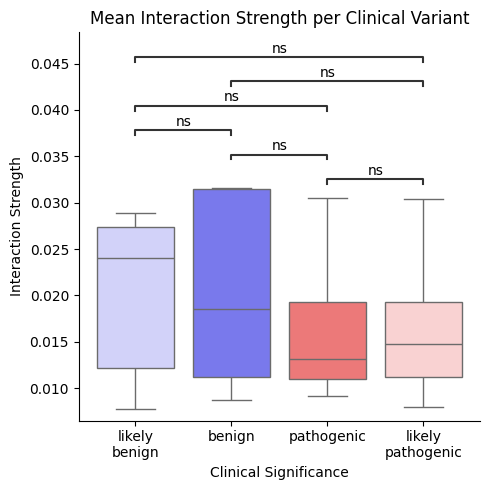

In [78]:
clinsig_boxplot = ab.plot_clinsig_interaction_strength(
    ridge_df=ridge_df,  
    site_col="site",
    x="CLNSIG_simple",
)

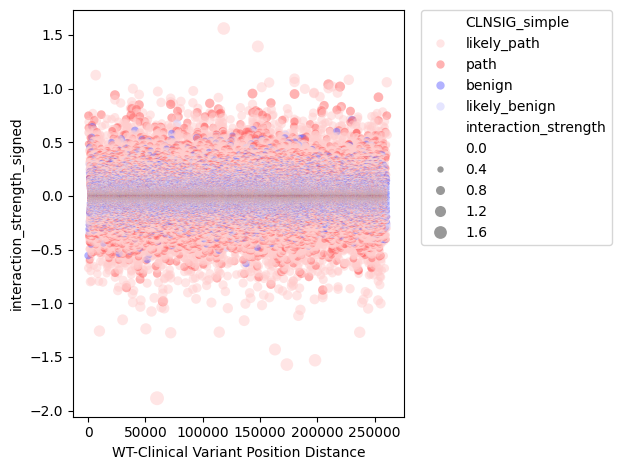

In [79]:
palette = utils.get_clinsig_palette()
# scatter_df utils.sort_by_clinsig(ridge_df.loc[~ridge_df["wt_variant"].str.endswith(">")])
ax = sns.scatterplot(
    x="position_distance", 
    y="interaction_strength_signed",
    size="interaction_strength",
    hue="CLNSIG_simple",
    palette=palette,
    sizes=(0.0001,100),
    alpha=0.5,
    data=ridge_df
)
plt.xlabel("WT-Clinical Variant Position Distance")
# Place the legend outside to the right
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()

Test whether there's a relationship between the LD and interaction strength.

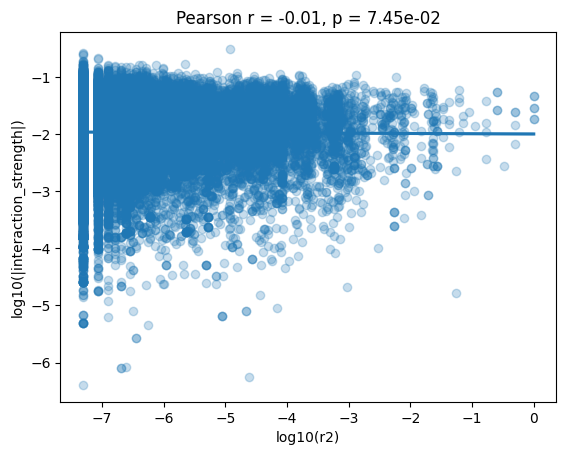

In [80]:
if 'Xld' not in globals():
    Xld = np.corrcoef(hap_matrix, rowvar=False) 

# Precompute mapping from wt_variant and clinical_position to Xld indices for speed
pos_to_idx = {int(str(name).split(":")[1].split("-")[0]): i for i, name in enumerate(Xwt.columns)}

def fast_get_r(row):
    x_idx = pos_to_idx.get(row["wt_position"], None)
    y_idx = pos_to_idx.get(row["clinical_position"], None)
    if x_idx is not None and y_idx is not None:
        return Xld[x_idx, y_idx]
    else:
        return np.nan

ridge_df["r"] = ridge_df.apply(fast_get_r, axis=1)
ridge_df["r2"] = ridge_df["r"]**2


from scipy.stats import pearsonr

# Compute log10 values
log_r2 = np.log10(ridge_df["r2"] + 1e-8)
log_interaction_strength = np.log10(ridge_df["interaction_strength"].abs() + 1e-8)

# Remove NaNs and infs for correlation and plotting
mask = (
    log_r2.notna() & log_interaction_strength.notna() &
    np.isfinite(log_r2) & np.isfinite(log_interaction_strength)
)
log_r2_clean = log_r2[mask]
log_interaction_strength_clean = log_interaction_strength[mask]

# Plot
sns.regplot(
    x=log_r2_clean, 
    y=log_interaction_strength_clean,
    scatter_kws={'alpha':0.25}
)
plt.xlabel("log10(r2)")
plt.ylabel("log10(|interaction_strength|)")

# Pearson correlation
if len(log_r2_clean) > 1:
    pearson_r, pearson_p = pearsonr(log_r2_clean, log_interaction_strength_clean)
    plt.title(f"Pearson r = {pearson_r:.2f}, p = {pearson_p:.2e}")
else:
    plt.title("Not enough data for Pearson correlation")

## Annotate variant sensitization maps







In [17]:
vep_df

,index,site,sample,ploid,slot,evo2_40b_base,evo2_7b_base,evo2_7b,spliceai_mm,spliceai,evo2_40b,flashzoi,dnabert2,__null_dask_index__,VEP
0,214116,chr17:7675232-7675233_G_A,REF,0,COVR,NaN,NaN,NaN,NaN,NaN,NaN,0.448245,NaN,214116,0.448245
1,214130,chr17:7675232-7675233_G_A,REF,1,COVR,NaN,NaN,NaN,NaN,NaN,NaN,0.561821,NaN,214130,0.561821
2,214144,chr17:7675232-7675233_G_A,HG00096,0,COVR,NaN,NaN,NaN,NaN,NaN,NaN,0.469391,NaN,214144,0.469391
3,214158,chr17:7675232-7675233_G_A,HG00096,1,COVR,NaN,NaN,NaN,NaN,NaN,NaN,0.530744,NaN,214158,0.530744
4,214172,chr17:7675232-7675233_G_A,HG00097,0,COVR,NaN,NaN,NaN,NaN,NaN,NaN,0.745940,NaN,214172,0.745940
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2238017,73156230,chr17:7670630-7670631_C_G,NA21142,1,COVR,NaN,NaN,NaN,NaN,NaN,NaN,0.555934,NaN,73156230,0.555934
2238018,73156244,chr17:7670630-7670631_C_G,NA21143,0,COVR,NaN,NaN,NaN,NaN,NaN,NaN,0.556963,NaN,73156244,0.556963
2238019,73156258,chr17:7670630-7670631_C_G,NA21143,1,COVR,NaN,NaN,NaN,NaN,NaN,NaN,0.799945,NaN,73156258,0.799945
2238020,73156272,chr17:7670630-7670631_C_G,NA21144,0,COVR,NaN,NaN,NaN,NaN,NaN,NaN,0.794079,NaN,73156272,0.794079


## Compare variant sensitization maps to ABC maps


Test whether there is substantial enrichment (or any overlap) between WT-Clinical variant interactions we derived from our sensitization maps, and the interctions defined in functional datasets like Activity By Contact (ABC) maps.


Data source:
https://www.engreitzlab.org/resources

In [ ]:
# abc = pl.scan_csv("https://mitra.stanford.edu/engreitz/oak/public/Nasser2021/AllPredictions.AvgHiC.ABC0.015.minus150.ForABCPaperV3.txt.gz", 
#                   separator="\t").filter(
#                       pl.col("chr") == chrom
#                       ).collect().to_pandas()

abc = pd.read_csv("https://mitra.stanford.edu/engreitz/oak/public/Nasser2021/AllPredictions.AvgHiC.ABC0.015.minus150.ForABCPaperV3.txt.gz", 
                  sep="\t")
print(abc.shape)
abc.head() 

In [156]:
import src.pyliftover as pf

abc_chrom = pf.liftover(
    df=abc.loc[(abc["chr"] == chrom)].copy(),
    from_build='hg19',
    to_build='hg38',
    chrom_col='chr',
    position_cols=['start', 'end']
)

Define anchors around each ABC contact pair (+/- `anchor_size` at each end). 

If the clinical variant falls in one anchor and the WT variant falls in the other corresponding anchor (or vice versa), we can consider this a "hit".

In [ ]:
import pyranges as pr
import pandas as pd

print("Filtering ABC contacts to gene region...")

anchor_size = 500
min_interaction_strength = 0.01

# Subset to gene region (with anchor padding)
abc_sub = abc_chrom.loc[(abc_chrom["start_hg38"] >= gene_min_pos-anchor_size) & (abc_chrom["end_hg38"] <= gene_max_pos+anchor_size)].copy()
# Aggregate by anchor region
abc_sub = abc_sub.groupby(["chr","start_hg38","end_hg38","name","class"]).agg({"ABC.Score": "max"}).reset_index()
if abc_sub.empty:
    raise ValueError("abc_sub contains no remaining rows")
print(f"ABC contacts in region: {len(abc_sub)}")



# --- Efficient anchor construction using PyRanges ---
print("Defining ABC anchors (PyRanges)...") 
anchor1 = pr.PyRanges(
    pd.DataFrame({
    "Chromosome": abc_sub["chr"].values,
    "Start": (abc_sub["start_hg38"] - anchor_size).values,
    "End": (abc_sub["start_hg38"] + anchor_size).values,
    "anchor_id": abc_sub.index.values,
    "anchor_type": ["anchor1"] * len(abc_sub)
    })
)
anchor2 = pr.PyRanges(
    pd.DataFrame({
    "Chromosome": abc_sub["chr"].values,
    "Start": (abc_sub["end_hg38"] - anchor_size).values,
    "End": (abc_sub["end_hg38"] + anchor_size).values,
    "anchor_id": abc_sub.index.values,
    "anchor_type": ["anchor2"] * len(abc_sub)
    })
)
abc_anchors_pr = pr.concat([anchor1, anchor2])
print(f"Total ABC anchors: {len(abc_anchors_pr)}")

# --- Ridge variant PyRanges ---
print("Preparing ridge variant PyRanges...")

ridge_df_sub = ridge_df.loc[ridge_df['interaction_strength'] > min_interaction_strength].copy()
ridge_df_sub["chr"] = ridge_df_sub["site"].str.split(":").str[0]

wt_pr = pr.PyRanges(
    pd.DataFrame({
    "Chromosome": ridge_df_sub["chr"].values,
    "Start": ridge_df_sub["wt_position"].values,
    "End": (ridge_df_sub["wt_position"] + 1).values,
    "ridge_id": ridge_df_sub.index.values,
        "var_type": ["wt"] * len(ridge_df_sub)
    })
)
clin_pr = pr.PyRanges(
    pd.DataFrame({
    "Chromosome": ridge_df_sub["chr"].values,
    "Start": ridge_df_sub["clinical_position"].values,
    "End": (ridge_df_sub["clinical_position"] + 1).values,
    "ridge_id": ridge_df_sub.index.values,
    "var_type": ["clinical"] * len(ridge_df_sub)
    })
)

ridge_vars_pr = pr.concat([wt_pr, clin_pr])
print(f"Total ridge variant positions: {len(ridge_vars_pr)}")

# --- Overlap: join in both directions, then groupby in PyRanges ---
print("Finding overlaps between ridge variants and ABC anchors (PyRanges)...")
overlaps = ridge_vars_pr.join(abc_anchors_pr, suffix="_anchor")
overlap_df = overlaps.df
print(f"Total overlaps found: {len(overlap_df)}")

# --- Use groupby in pandas for fast anchor-pair matching ---
print("Finding ridge-ABC pairs with both wt and clinical in different anchors (fast groupby)...")
# Only keep necessary columns
overlap_df = overlap_df[["ridge_id", "var_type", "anchor_id", "anchor_type"]]

# Group by ridge_id and anchor_id, collect anchor_types and var_types
grouped = overlap_df.groupby(["ridge_id", "anchor_id"])
def anchor_pair_match(df):
    types = set(zip(df["var_type"], df["anchor_type"]))
    # Must have one (wt, anchor1) and one (clinical, anchor2) OR
    # one (wt, anchor2) and one (clinical, anchor1)
    return (
        (("wt", "anchor1") in types and ("clinical", "anchor2") in types) or
        (("wt", "anchor2") in types and ("clinical", "anchor1") in types)
    )
mask = grouped.filter(anchor_pair_match)
matches = mask.drop_duplicates(subset=["ridge_id", "anchor_id"])[["ridge_id", "anchor_id"]]

print(f"Number of matching ridge-ABC pairs: {len(matches)}")

# Merge back to get full ridge_df and abc_chrom info
if not matches.empty:
    print("Merging matches with ridge_df and abc_sub for full annotation...")
    matches = matches.merge(ridge_df_sub.reset_index().rename(columns={"index": "ridge_id"}), on="ridge_id", how="left")
    matches = matches.merge(abc_sub.reset_index().rename(columns={"index": "anchor_id"}), on="anchor_id", how="left")
overlap_df = matches

print("First few rows of overlap_df:")
overlap_df.head()


Filtering ABC contacts to gene region...
ABC contacts in region: 2922
Defining ABC anchors (PyRanges)...
Total ABC anchors: 5844
Preparing ridge variant PyRanges...
Total ridge variant positions: 1455564
Finding overlaps between ridge variants and ABC anchors (PyRanges)...
Total overlaps found: 8926958
Finding ridge-ABC pairs with both wt and clinical in different anchors (fast groupby)...
Number of matching ridge-ABC pairs: 60
Merging matches with ridge_df and abc_sub for full annotation...
First few rows of overlap_df:


,ridge_id,anchor_id,wt_variant,site,interaction_strength,interaction_strength_signed,outlier_type,n_haplotypes,interaction_strength_weighted,clinical_variant,wt_position,clinical_position,position_distance,chrom,chromStart,chromEnd,name,score,REF,ALT,MC_id,MC_term,AF_ESP,AF_EXAC,AF_TGP,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNVC,CLNVCSO,CLNSIGCONF,GENEINFO,MC,ORIGIN,RS,ONC,ONCDN,ONCDISDB,ONCREVSTAT,ONCCONF,SCI,SCIDN,SCIDISDB,SCIREVSTAT,CLNREVSTAT_score,MONDO,MONDO_n,OMIM,OMIM_n,Orphanet,Orphanet_n,MedGen,MedGen_n,MeSH,MeSH_n,CLNSIG_simple,CLNSIG_super_simple,GENE,chr_x,chr_y,start_hg38,end_hg38,ABC.Score
0,109227,1470,chr17:7667128-7667129_G_A,chr17:7669124-7669125_C_T,0.065226,0.065226,more benign,1,0.255394,chr17:7669124-7669125_C_T,7667128,7669124,1996,17,7669124,7669125,chr17:7669124-7669125_C_T,2.0,C,T,SO:0001624,3_prime_UTR_variant,NaN,NaN,0.05112,340463,"Gene:553989,MedGen:C1835398,OMIM:151623,Orphan...",Li-Fraumeni_syndrome_1|Hereditary_cancer-predi...,NC_000017.11:g.7669124C>T,"criteria_provided,_multiple_submitters,_no_con...",Benign,single_nucleotide_variant,SO:0001483,None,TP53:7157,SO:0001624|3_prime_UTR_variant,1,4968187.0,None,None,None,None,None,None,None,None,None,2,[MONDO:MONDO:0015356],1,[OMIM:151623],1,"[Orphanet:524, Orphanet:140162]",2,"[MedGen:C1835398, MedGen:C0027672, MedGen:C366...",3,[MeSH:D009386],1,benign,benign,TP53,chr17,chr17,7667462,7668672,0.037489
1,150584,1470,chr17:7667061-7667062_C_T,chr17:7669124-7669125_C_T,0.050614,-0.050614,more pathogenic,3,0.389668,chr17:7669124-7669125_C_T,7667061,7669124,2063,17,7669124,7669125,chr17:7669124-7669125_C_T,2.0,C,T,SO:0001624,3_prime_UTR_variant,NaN,NaN,0.05112,340463,"Gene:553989,MedGen:C1835398,OMIM:151623,Orphan...",Li-Fraumeni_syndrome_1|Hereditary_cancer-predi...,NC_000017.11:g.7669124C>T,"criteria_provided,_multiple_submitters,_no_con...",Benign,single_nucleotide_variant,SO:0001483,None,TP53:7157,SO:0001624|3_prime_UTR_variant,1,4968187.0,None,None,None,None,None,None,None,None,None,2,[MONDO:MONDO:0015356],1,[OMIM:151623],1,"[Orphanet:524, Orphanet:140162]",2,"[MedGen:C1835398, MedGen:C0027672, MedGen:C366...",3,[MeSH:D009386],1,benign,benign,TP53,chr17,chr17,7667462,7668672,0.037489
2,151356,1470,chr17:7667611-7667612_C_T,chr17:7668539-7668540_G_A,0.050407,0.050407,more benign,3765,13.776133,chr17:7668539-7668540_G_A,7667611,7668539,928,17,7668539,7668540,chr17:7668539-7668540_G_A,2.0,G,A,SO:0001624,3_prime_UTR_variant,NaN,NaN,0.00779,347484,"MedGen:C3661900|MONDO:MONDO:0015356,MeSH:D0093...",not_provided|Hereditary_cancer-predisposing_sy...,NC_000017.11:g.7668539G>A,"criteria_provided,_multiple_submitters,_no_con...",Benign/Likely_benign,single_nucleotide_variant,SO:0001483,None,TP53:7157,SO:0001624|3_prime_UTR_variant,1,114831472.0,None,None,None,None,None,None,None,None,None,2,[MONDO:MONDO:0015356],1,[OMIM:151623],1,"[Orphanet:140162, Orphanet:524]",2,"[MedGen:C3661900, MedGen:C0027672, MedGen:C183...",3,[MeSH:D009386],1,likely_benign,benign,TP53,chr17,chr17,7667462,7668672,0.037489
3,198171,1470,chr17:7667362-7667363_G_A,chr17:7668539-7668540_G_A,0.040745,-0.040745,more pathogenic,4,0.403706,chr17:7668539-7668540_G_A,7667362,7668539,1177,17,7668539,7668540,chr17:7668539-7668540_G_A,2.0,G,A,SO:0001624,3_prime_UTR_variant,NaN,NaN,0.00779,347484,"MedGen:C3661900|MONDO:MONDO:0015356,MeSH:D0093...",not_provided|Hereditary_cancer-predisposing_sy...,NC_000017.11:g.7668539G>A,"criteria_provided,_multiple_submitters,_no_con...",Benign/Likely_benign,single_nucleotide_variant,SO:0001483,None,TP53:7157,SO:0001624|3_prime_UTR_variant,1,114831472.0,None,None,None,None,None,None,None,None,None,2,[MONDO:MONDO:0015356],1,[OMIM:151623],1,"[Orphanet:140162, Orphanet:524]",2,"[MedGen:C3661900, MedGen:C0027672, MedGen:C183...",3,[MeSH:D009386],1,likely_benign,benign,TP53,chr17,chr17,7667462,7668672,0.037489
4,217957,1470,chr17:7667706-7667707_G_A,chr17:7668783-7668784_C_T,0.037679,0.037679,more benign,16,0.776443,chr17:7668783-7668784_C_T,7667706,766

<Axes: xlabel='interaction_strength', ylabel='ABC.Score'>

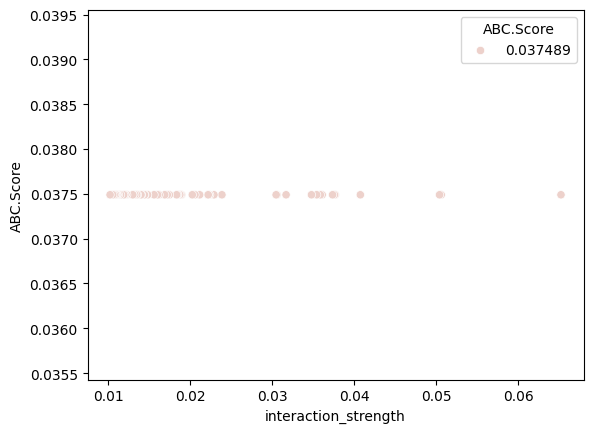

In [219]:
sns.scatterplot(data=overlap_df, x="interaction_strength", y="ABC.Score", hue="ABC.Score")

In [221]:
abc_sub

,chr,start_hg38,end_hg38,ABC.Score
0,chr17,7418979,7419179,0.020327
1,chr17,7429461,7430058,0.016144
2,chr17,7435011,7437248,0.189394
3,chr17,7435012,7435912,0.138041
4,chr17,7435175,7435935,0.147719
...,...,...,...,...
2917,chr17,7922913,7923113,0.024458
2918,chr17,7922927,7923127,0.019590
2919,chr17,7922931,7923131,0.018537
2920,chr17,7923274,7923474,0.015745


In [ ]:
abc_sub["anchor1"] = abc_sub["chr"] +":"+ abc_sub["start_hg38"].astype(str)
abc_sub["anchor2"] = abc_sub["chr"] +":"+ abc_sub["end_hg38"].astype(str)
 
Xabc = mc.fill_coordinates(abc_sub, 
                           full_length=gene_max_pos-gene_min_pos+1,
                           x_id_col='anchor1',
                           y_id_col='anchor2',
                           x_pos_col='start_hg38',
                           y_pos_col='end_hg38',
                           value_col="ABC.Score",
                           aggfunc="max", 
                           )

<string>:26: PerformanceWarning: The following operation may generate 269103118200 cells in the resulting pandas object.


In [ ]:
Xabc = mc.fill_coordinates(abc_sub, 
                           full_length=gene_max_pos-gene_min_pos+1,
                           x_id_col='name',
                            y_id_col='class',
                            x_pos_col='start_hg38',
                            y_pos_col='end_hg38',
                            value_col="ABC.Score",
                            aggfunc="max", 
                            )
Xabc.shape
 

(2530, 2483)

/tmp/ipykernel_3894547/368689104.py:1: FutureWarning: The provided callable <function nanmax at 0x7f5eadb93060> is currently using DataFrameGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  Xabc = abc_sub.pivot_table(index="start_hg38", columns="end_hg38", values="ABC.Score", aggfunc=np.nanmax)
<string>:28: RuntimeWarning: All-NaN slice encountered


(2530, 2483)


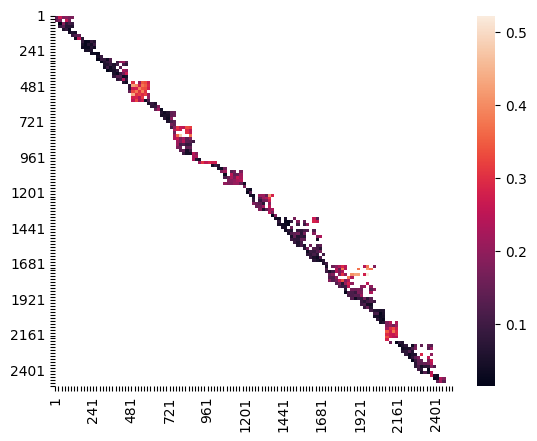

In [211]:
Xabc = abc_sub.pivot_table(index="start_hg38", columns="end_hg38", values="ABC.Score", aggfunc=np.nanmax) 
print(Xabc.shape)

bin_size = 20
Xabc_binned = mc.bin_matrix(Xabc, bin_size=bin_size, agg_func=np.nanmax)

sns.heatmap(Xabc_binned)

mc.label_bins(bin_size=bin_size, n_bins=Xabc.shape[0]//bin_size)

In [207]:
abc_sub_agg = abc_sub.groupby(["name","start_hg38","end_hg38"]).agg({"ABC.Score": "mean"}).reset_index().rename(columns={"name": "abc_name"})
abc_sub_agg.head()


,abc_name,start_hg38,end_hg38,ABC.Score
0,genic|chr17:7322148-7322648,7418979,7419179,0.020327
1,genic|chr17:7339292-7340666,7436123,7437197,0.040927
2,genic|chr17:7339530-7340673,7436361,7437204,0.043298
3,genic|chr17:7339586-7340086,7436417,7436617,0.018062
4,genic|chr17:7339622-7340894,7436453,7437425,0.043763


In [209]:
abc_sub_agg.merge(ridge_df, left_on=["start_hg38","end_hg38"], right_on=["wt_position","clinical_position"], how="inner")

,abc_name,start_hg38,end_hg38,ABC.Score,wt_variant,site,interaction_strength,interaction_strength_signed,outlier_type,n_haplotypes,interaction_strength_weighted,clinical_variant,wt_position,clinical_position,position_distance,chrom,chromStart,chromEnd,name,score,REF,ALT,MC_id,MC_term,AF_ESP,AF_EXAC,AF_TGP,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNVC,CLNVCSO,CLNSIGCONF,GENEINFO,MC,ORIGIN,RS,ONC,ONCDN,ONCDISDB,ONCREVSTAT,ONCCONF,SCI,SCIDN,SCIDISDB,SCIREVSTAT,CLNREVSTAT_score,MONDO,MONDO_n,OMIM,OMIM_n,Orphanet,Orphanet_n,MedGen,MedGen_n,MeSH,MeSH_n,CLNSIG_simple,CLNSIG_super_simple,GENE,chr


In [210]:
abc_sub_agg.merge(ridge_df, left_on=["start_hg38","end_hg38"], right_on=["clinical_position","wt_position"], how="inner")

,abc_name,start_hg38,end_hg38,ABC.Score,wt_variant,site,interaction_strength,interaction_strength_signed,outlier_type,n_haplotypes,interaction_strength_weighted,clinical_variant,wt_position,clinical_position,position_distance,chrom,chromStart,chromEnd,name,score,REF,ALT,MC_id,MC_term,AF_ESP,AF_EXAC,AF_TGP,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNVC,CLNVCSO,CLNSIGCONF,GENEINFO,MC,ORIGIN,RS,ONC,ONCDN,ONCDISDB,ONCREVSTAT,ONCCONF,SCI,SCIDN,SCIDISDB,SCIREVSTAT,CLNREVSTAT_score,MONDO,MONDO_n,OMIM,OMIM_n,Orphanet,Orphanet_n,MedGen,MedGen_n,MeSH,MeSH_n,CLNSIG_simple,CLNSIG_super_simple,GENE,chr
